In [1]:
# import os

# def create_subfolders(parent_directory, subfolder_names, nested_subfolder_names):
#     for folder_name in subfolder_names:
#         # Construct the full path for the new subfolder
#         subfolder_path = os.path.join(parent_directory, folder_name)
#         try:
#             # Create the main subfolder
#             os.makedirs(subfolder_path)
#             print(f"Created subfolder: {subfolder_path}")

#             # Create nested subfolders
#             for nested_folder_name in nested_subfolder_names:
#                 nested_subfolder_path = os.path.join(subfolder_path, nested_folder_name)
#                 os.makedirs(nested_subfolder_path)
#                 print(f"Created nested subfolder: {nested_subfolder_path}")
#         except OSError as error:
#             print(f"Error creating subfolder {subfolder_path}: {error}")

# # Define the parent directory
# parent_directory = "solns_runs/Ex5"

# # Generate main subfolder names T1, T2, ..., T50
# T_max= 3
# subfolder_names = [f"T{i}" for i in range(1, T_max)]

# # Generate nested subfolder names N100, N200, ..., N1500
# nested_subfolder_names = [f"N{i}" for i in range(100, 1501, 100)]

# # Create the subfolders
# create_subfolders(parent_directory, subfolder_names, nested_subfolder_names)

In [3]:
import numpy as np
import itertools
from scipy.optimize import minimize

# Define objective functions for each player
def player1_objective(x):
    return -x[0]

def player2_objective(x):
    return -x[1]


# Define constraints for each player
def constraint_function1(x):
    return 1-(0.5*x[0]+x[1])

def constraint_function2(x):
    return 1-(x[0]+0.5*x[1])

# def grad_cons1(x):
#   return np.array([-3.25, -1.25, -4.125])

def constraint_function(x):
  return np.array([constraint_function1(x),constraint_function2(x)])



def grad_cons_x_1(x):
  return np.array([0.5, 1])

def grad_cons_x_2(x):
  return np.array([1.0, 0.5])

b1 = [(0.0,1)]
b2 = [(0.0, 1)]
constraints = [
    {'type': 'ineq', 'fun': constraint_function1},
    {'type': 'ineq', 'fun': constraint_function2},
]

def F(x,lamd):
    # return np.array([alpha1*x[0]+beta*(x[0]+x[1]+x[2])-c1+x[0]*(alpha1+beta),alpha2*x[1]+beta*(x[0]+x[1]+x[2])-c2+x[1]*(alpha2+beta), alpha3*x[2]+beta*(x[0]+x[1]+x[2])-c3+x[2]*(alpha3+beta)])+lamd[0]*grad_cons1(x)+lamd[1]*grad_cons2(x)

    return np.array([-1+lamd@grad_cons_x_1(x),-1+lamd@grad_cons_x_2(x)])

def project_into_feasible_set(x,constraint_function):
    result = minimize(lambda x_prime: np.linalg.norm(x_prime - x), x, constraints= constraints,bounds= [b1[0],b2[0]])
    return result.x

# num_iterations= 100
def projected_gradient_descent_kkt(F,initial_x, initial_y, lambda_value,lamd):
    x = initial_x.copy()
    y = initial_y.copy()


    grad_obj = F(y,lamd)
    x = project_into_feasible_set(x - lambda_value * grad_obj,constraint_function)
    return x



#------------------- Projected gradient VI solver -------------------
def vi_solver(lamd):
    alpha= np.random.uniform(0, sqrt(2)-1)
    x = np.random.uniform(low=0.0, high= 1, size = 1) #14, 15, 30
    y = np.random.uniform(low=0.0, high= 1, size = 1)
    z0 = np.concatenate((np.expand_dims(x, axis=1),np.expand_dims(y, axis=1)), 1)
    x0= z0
    y0= x0.copy()

    T= 1000
    n= 2
    x,y= np.zeros((T+1,n)),np.zeros((T+1,n))
    x[0]= x0
    y[0]= y0
    lambda_value_0= np.random.uniform(0, alpha)

    x[1]= projected_gradient_descent_kkt(F,x[0], y[0], lambda_value_0, lamd)
    y[1]= 2*x[1]-x[0]
    for i in range(1,T):

        if np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))!= 0.0:
            lambda_value= np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd)))
        else:
            lambda_value= 1e-8 # np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))+1e-8)
      # break
#         print(x[i])
        x[i+1]= projected_gradient_descent_kkt(F,x[i], y[i], lambda_value,lamd)
        y[i+1]= 2*x[i+1]-x[i]
#         print(x[i+1])
        
#         print(np.linalg.norm(x[i+1] - x[i]))
        
        if (np.linalg.norm(x[i+1] - x[i])) <= 1e-4:
            if np.all(np.abs(constraint_function(x[i+1]) * lamd) <= 1e-4):
                return x[i+1]


In [4]:
import random

def discretize_3d_space(T, num_points):
    """
    Sample num_points random points in 2D domain [0, T] x [0, T].

    Parameters:
    - T: Upper bound of domain
    - num_points: Total number of 2D points

    Returns:
    - points: List of (x, y) tuples
    """
    points = [(random.uniform(0, T), random.uniform(0, T)) 
              for _ in range(num_points)]
    
    return points

In [5]:
# l= discretize_3d_space(T= 5, num_points= 200)
# l

In [6]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
# from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()


eps_t= 1e-5
delta= 1e-3 #1e-2
delta

def calculate_distance(point1, point2):
    # Calculate the Euclidean distance between two points of any dimension
    return sum((x - y)** 2 for x, y in zip(point1, point2)) ** 0.5
#     return sum(abs(x - y) for x, y in zip(point1, point2))

    
# delta= 0.00001 #1e-2
def count_repeated_points(points):
    # Initialize a list to store distinct points
    distinct_points = []

    # Iterate through each point in the set
    for point in points:
        # Check if the point is distinct from all previously considered distinct points
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < delta:
                is_distinct = False
                break
        # If the point is distinct, add it to the list of distinct points
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points



def organize_solutions(solns):
    set_of_points= []
    for sol in solns:
        if sol is not None:
            set_of_points.append(list(sol))

    return set_of_points




def run_for_lam(lmb):
    results = Parallel(n_jobs=8,prefer= 'threads')(delayed(vi_solver)(lam) for lam in lmb)
    set_of_points= organize_solutions(results)
    return set_of_points

def run_(lambd):
    results = Parallel(n_jobs=-1,prefer= 'threads')(delayed(run_for_lam)(lam) for lam in lambd)
    set_of_points= organize_solutions(results)
    return set_of_points

def run_n(lmb, n_r= 10):
    results = Parallel(n_jobs=8)(delayed(run_for_lam)(lmb) for _ in range(n_r))
    set_of_points= organize_solutions(results)
    res= []
    for i in set_of_points:
        res.extend(i)
    return np.array(res)


def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=-1,prefer= 'threads')(delayed(run_)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points


def run_for_different_runs(T,n_r= 5):
    lambd = Parallel(n_jobs=-1,prefer= 'threads')(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
    result= run_for_lam_run(lambd,n_r)
    #return result.
    for idx_run in range(n_r):
        results= result[idx_run]
        for n_points in range(len(results)):
            np.savetxt('./solns_runs/Ex5/T'+str(T)+'/'+'N'+str(number_points_list[n_points])+"/"+str(idx_run+1)+"_"+"solns"+'_'+'run'+str(n_r)+'_'+str(number_points_list[n_points])+'pts'+'.txt', np.array(results[n_points]), delimiter=',')
            
        

    
# Parallel(n_jobs=-1,prefer= 'threads')(delayed(run_for_different_runs)(T) for T in T_list)

In [7]:
number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
# n_runs= [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60]
# number_points_list= [10, 20]
# T_list= [T for T in range(1,T_max)]
# n_runs= [5]
T= 2
lambd= Parallel(n_jobs=-1)(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
lambd

[[(0.6299934782169312, 0.4100100680361982),
  (0.4999936680843178, 0.6360564639405715),
  (1.6169887309170337, 0.049684935513973016),
  (0.522300861445739, 1.7328104617844178),
  (0.4352367823507943, 0.6851284864078617),
  (1.4653383725030589, 0.24343497246697066),
  (1.7512761088988267, 0.8190786042535894),
  (1.7990676916478276, 0.8923797972721605),
  (0.21738945196766601, 1.4666901932532614),
  (0.1313686621899821, 0.7306312195267071),
  (0.09109824988793624, 1.790207322015302),
  (1.2194266100764535, 1.541731712336196),
  (1.458823081634426, 0.45363239528390165),
  (0.3131689253007539, 0.827621084799488),
  (0.3176150632505974, 1.580828953531229),
  (0.6639424996697401, 0.6022243684534287),
  (1.1899912026182524, 0.0799672401305842),
  (0.5075674894175846, 0.34015529753479345),
  (1.040300622539101, 0.6030559433308067),
  (0.38372407919926776, 1.4535526278793516),
  (1.351575011744229, 1.202838376860115),
  (1.5225837936609405, 0.9330017421406525),
  (0.9051808061998763, 0.85898394

In [69]:
# lambd[0]

In [13]:
len(lambd[1])

200

In [15]:
n_runs= 10

In [17]:
vi_solver(lamd=(0.0,0.0))

array([0.13014641, 0.84643967])

In [80]:
len(lambd[0])

100

In [ ]:
tt= run_for_lam(lambd[0])

In [20]:
tt

[[0.6666666666666667, 0.6666666666666666],
 [0.6666666666666666, 0.6666666666666666],
 [0.6666666666666667, 0.6666666666666666],
 [0.6666666666666666, 0.6666666666666667],
 [0.6666666666666666, 0.6666666666666666],
 [0.6666666666666667, 0.6666666666666666],
 [0.6666666666666666, 0.6666666666666666],
 [0.6666666666666666, 0.6666666666666667],
 [0.6666666666666667, 0.6666666666666666],
 [0.6666666666666666, 0.6666666666666667],
 [0.6666666666666667, 0.6666666666666666],
 [0.6666666666666666, 0.6666666666666667],
 [0.6666666666666666, 0.6666666666666666],
 [0.6666666666666666, 0.6666666666666666]]

In [19]:
# lambd = Parallel(n_jobs=6)(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
# lambd

In [21]:
# data= []
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [23]:
# data= np.array(data)

In [25]:
# data[0]

In [27]:
# for i in range(len(data)):
#     fig = plt.figure(figsize=(15,6))
#     ax = fig.add_subplot(111, projection='3d')
    
#     # Plot the curve in 3D
#     ax.scatter(np.array(data[i])[:,0], np.array(data[i])[:,1], np.array(data[i])[:,2], c= 'red', label= "Solution set")
#     ax.set_xlim(0.0, 8.0)
#     ax.set_ylim(3.0, 11.)
#     ax.set_zlim(0.0, 8.0)
#     ax.set_xlabel(r'$x_1$')
#     ax.set_ylabel(r'$x_2$')
#     ax.set_zlabel(r'$x_3$')
    
#     plt.legend()
#     ax.set_title("Solution set found by VPI")
#     # plt.savefig('Ex1.jpeg', format='jpeg')
#     # fig.savefig('ex1.png', dpi=180, bbox_inches='tight')
#     # plt.savefig('Ex5.png', dpi=180, bbox_inches='tight')
#     plt.show()

In [30]:
# lambd = Parallel(n_jobs=6)(delayed(discretize_3d_space)(1, num_points) for num_points in number_points_list)

In [32]:
# res= runT(T= 2)

In [35]:
## All T

In [37]:
def runT(T):
    lambd = Parallel(n_jobs=6)(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
    data= []
    for l in range(len(lambd)):
        res= run_n(lambd[l])
        data.append(res)
    return data

In [39]:
T_list= [1, 2, 3, 4, 5, 6, 8]

T_data= dict.fromkeys(range(1, len(T_list)+1), 0)

T_data

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

In [41]:
for T in T_list:
    print("Running for T= ", T)
    res= runT(T)
    T_data[T]= res
    print(len(res))

Running for T=  1
15
Running for T=  2
15
Running for T=  3
15
Running for T=  4
15
Running for T=  5
15


In [42]:
import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex7PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

In [28]:
with open("Ex7PVIT.json", "r") as f:
    T_data = json.load(f)

with open("Ex7PVIT910.json", "r") as f:
    T_data678 = json.load(f)
# T_data[str(5)]
T_data["9"] = T_data678["9"]
T_data["10"] = T_data678["10"]

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")
    
# Save again
with open("Ex7PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

In [17]:
# T_data["8"]

# Track $T_{max}$

In [29]:
import json
import numpy as np

import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]


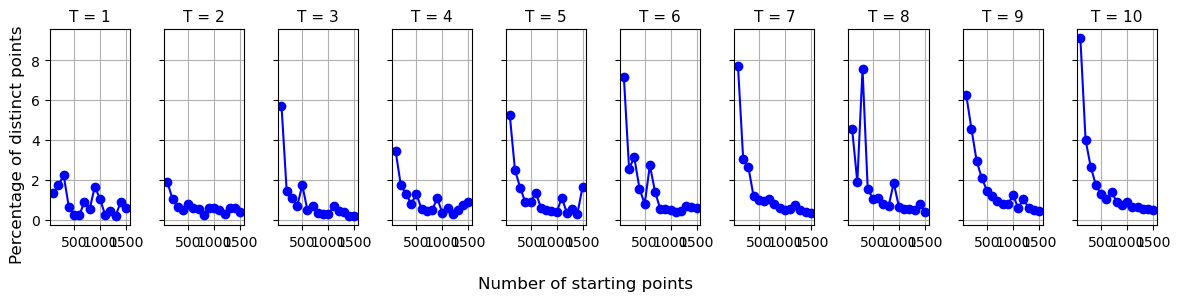

In [30]:
with open('./Ex7PVIT.json') as f:
    dataT= json.load(f)
    
    
T_list= [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] # T= 1 is the one giving meaningfull solution[1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)




for T in T_list:
    data_all= []

    for i in range(len(number_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[str(T)][i])):
                # print(data[str(i)][t])
                #if np.abs(constraint_function(dataT[str(T)][i][t]))< 1e-6:
                res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all
    
    
res_all= []

for i in range(len(number_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)
    
data_all= res_all


dt_res= []

for i in range(len(number_points_list)):
    cleaned_data = [x for x in data_all[i] if x != []]
    # print(cleaned_data)
    dt_res.append(cleaned_data)
    # break

data_all= dt_res


import numpy as np

def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

res_T= {
    1: None, 2: None, 3: None, 4: None, 5: None, 6: None, 7: None, 8: None, 9:None, 10:None
}
Tmax= 10

dist_= None
for t in range(1, Tmax+1):
    dist_= []

    for (idx, pt) in enumerate(number_points_list):




        num, distinct_points = count_repeated_points(np.array(data_dict[t][idx]))
        distinct_points= np.array(distinct_points)
        dist_.append((len(distinct_points)/(len(np.array(data_dict[t][idx]))))*100)
    res_T[t]= dist_

    
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(100, 1501, 100)

fig, axes = plt.subplots(1, Tmax, figsize=(12,3), sharex=True, sharey=True)

for T in range(1, Tmax+1):
    ax = axes[T-1]
    ax.plot(x, res_T[T], marker='o', c= 'blue')
    ax.set_title(f"T = {T}", fontsize=11)
    ax.grid(True)

# global labels
fig.supxlabel("Number of starting points", fontsize=12)
fig.supylabel("Percentage of distinct points", fontsize=12)

plt.tight_layout()
#plt.savefig("Ex7Tmax.png", dpi=300, bbox_inches="tight")
plt.show()

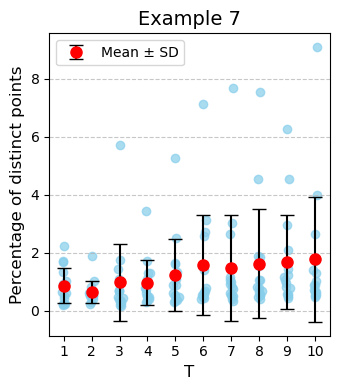

In [31]:
# Compute mean and std for each key
keys = list(res_T.keys())
means = [np.mean(res_T[k]) for k in keys]
stds = [np.std(res_T[k]) for k in keys]

plt.figure(figsize=(3.5,4))

# Plot all points with some horizontal jitter
for i, k in enumerate(keys):
    y = res_T[k]
    x = np.random.normal(loc=i+1, scale=0.05, size=len(y))  # jitter for visibility
    plt.scatter(x, y, color='skyblue', alpha=0.7, label='_nolegend_')

# Overlay mean as a red marker with error bars
plt.errorbar(keys, means, yerr=stds, fmt='o', color='red', ecolor='black', elinewidth=1.5,
             capsize=5, markersize=8, label='Mean ± SD')

# Formatting
plt.xticks(keys)
plt.xlabel('T', fontsize=12)
plt.ylabel('Percentage of distinct points', fontsize=12) # mean PDP across the number of starting points.
plt.title('Example 7', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("Ex7Tmax.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Run for T= 6, 7

In [29]:
# data= []

In [79]:
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [81]:
# all_data= dict.fromkeys(range(len(data)), 0)
# for i in range(len(data)):
#     all_data[i]= data[i]
    
# import json
# with open("Ex5PVI.json", "w") as f:
#     json.dump(all_data, f)